# CSE 2600 Homework 2

### Magdalena Danielewicz

## Question 1

In [44]:
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd

#### a. We’d like to organize this data into 3 groups, corresponding to high, medium, and low delivery days. Use smoothing by bin means to accomplish this, using a bin depth of 10. Illustrate your steps.

30 items in the dataset.  
30 / 10 = 3 bins  

Sorted data set: [2, 4, 5, 5, 6, 6, 6, 6, 6, 6, 6, 7, 7, 7, 7, 8, 8, 8, 8, 8, 8, 9, 9, 9, 11, 11, 11, 12, 12, 12]  

Bin 1: [2, 4, 5, 5, 6, 6, 6, 6, 6, 6]  
Bin 2: [6, 7, 7, 7, 7, 8, 8, 8, 8, 8]  
Bin 3: [8, 9, 9, 9, 11, 11, 11, 12, 12, 12]  

Means  
Bin 1: 5.2  
Bin 2: 7.4  
Bin 3: 10.4  

Final:  
Bin 1: [5.2, 5.2, 5.2, 5.2, 5.2, 5.2, 5.2, 5.2, 5.2, 5.2]  
Bin 2: [7.4, 7.4, 7.4, 7.4, 7.4, 7.4, 7.4, 7.4, 7.4, 7.4]  
Bin 3: [10.4, 10.4, 10.4, 10.4, 10.4, 10.4, 10.4, 10.4, 10.4, 10.4]  


#### b. Repeat the steps in part (a), this time using smoothing by bin medians into 3 bins of equal width.

Range = 12 - 2 = 10
Equal width = 10 / 3 = 3.33

Bin 1: [2, 4, 5, 5]  
Bin 2: [6, 6, 6, 6, 6, 6, 6, 7, 7, 7, 7, 8, 8, 8, 8, 8]  
Bin 3: [8, 9, 9, 9, 11, 11, 11, 12, 12, 12]

Medians:




#### c. Comment on which smoothing method, if any, you would prefer to use for the given data, giving reasons as to why.



# Question 2

In [47]:
from ISLP import load_data
Bikeshare = load_data('Bikeshare')
Bikeshare.columns

Index(['season', 'mnth', 'day', 'hr', 'holiday', 'weekday', 'workingday',
       'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'casual',
       'registered', 'bikers'],
      dtype='object')

#### a. Use the sm.OLS() function to perform a simple linear regression with bikers as the response and temp as the predictor. Use the summarize() function to print the results.

In [48]:
import statsmodels.api as sm
from ISLP.models import summarize
from ISLP import load_data

Bikeshare = load_data('Bikeshare')
Bikeshare.columns

Y = Bikeshare['bikers']
X = Bikeshare['temp']
X = sm.add_constant(X)

model = sm.OLS(Y, X)
results = model.fit()


print(f'Results: \n{summarize(results)}\n')
print(f'R2 value: {results.rsquared}')


Results: 
           coef  std err       t  P>|t|
const   -5.3745    3.423  -1.570  0.116
temp   305.0060    6.488  47.008  0.000

R2 value: 0.20361080146793864


#### b. Explain why we can deduce that there is a significant association between the predictor and the response.

From the results summary, we can see that the p-value for the temp slope is 0.000. When the p-value is less than 0.001, this means that there is a highly significant association between the bikers and the temperature.

#### c. How strong is the relationship between the predictor and the response? Use the R2 statistic to support your answer.

The R2 statistic here is 0.204, rounded to three decimal places. This means that 20.4% of the variability in biker count can be explained by the temperature. While temperature is a significant predictor (as we saw from the p-value), the relationship is only moderately strong since a majority of the variability is unexplained.

#### d. Is the relationship between the predictor and the response positive or negative? How can you tell?

The relationship between the predictor and the response is positive, since the coefficient of the temperature is positive at 305. This means that as temperature increases, the predicted number of bikers also increases.

#### e. According to this model, what is the predicted number of bikers on a day that averages the minimum temp?

Number of bikers = -5.3745 + (305.0060 * min(temp))  

In [49]:
min_temp = Bikeshare['temp'].min()
print(f'Minimum temperature: {min_temp}')

Minimum temperature: 0.02


Number of bikers = -5.3745 + (305.0600 * 0.02)  
                 = 0.7267 bikers
                 

#### f. Why might it be inappropriate to use this model to estimate the number of bikers on this day?

It's inappropriate to use this model for this estimation because it predicts that there will be 0.73 bikers on the day of the minimum temperature. Since the answer gave less than 1 and it's not possible to have fractional bikers on a day, this shows that a simple linear regression is not an appropriate model for this type of estimation.

#### g. Plot the response and the predictor in a new set of axes ax. Use the ax.axline() method or the abline() function defined in the lab to display the least squares regression line.

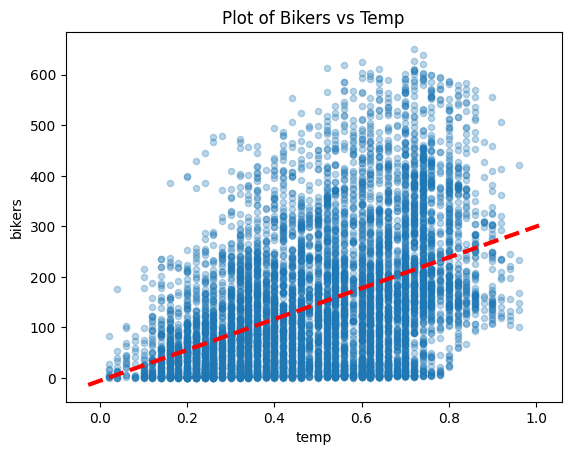

In [50]:
import numpy as np

def abline(ax, b, m, *args, **kwargs):
    """Plot a line from slope and intercept"""
    x_vals = np.array(ax.get_xlim())  
    y_vals = b + m * x_vals
    ax.plot(x_vals, y_vals, *args, **kwargs)

ax = Bikeshare.plot.scatter('temp', 'bikers', alpha=0.3)
ax.set_title("Plot of Bikers vs Temp")

abline(ax,
       results.params['const'],  
       results.params['temp'],   
       'r--',
       linewidth=3)

#### h. Produce a residual plot which compares the observed bikers values to the predicted ones.

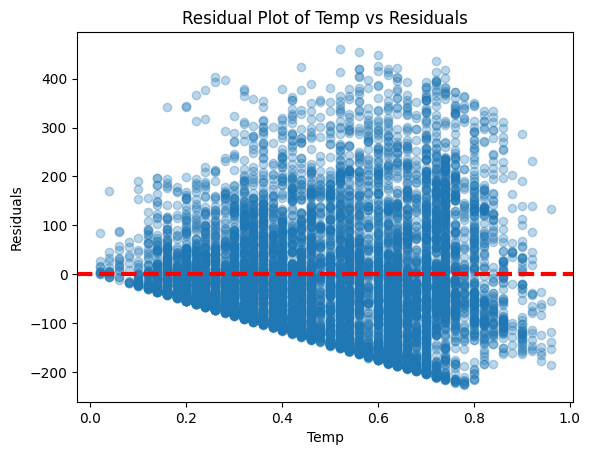

In [51]:

Y = Bikeshare['bikers']
X = Bikeshare['temp']
X = sm.add_constant(X)

model = sm.OLS(Y, X)
results = model.fit()
residuals = results.resid


plt.scatter(Bikeshare['temp'], residuals, alpha=0.3)
plt.axhline(0, color='red', linestyle='--', linewidth=3)
plt.title("Residual Plot of Temp vs Residuals")
plt.xlabel("Temp")
plt.ylabel("Residuals")
plt.show()

# Question 3

#### a. Compute the matrix of correlations between the numeric variables (including hr) using the corr() method.

In [52]:
import pandas as pd

Bikeshare['hr'] = pd.to_numeric(Bikeshare['hr'])
matrix = Bikeshare.select_dtypes(include='number').corr()

print(matrix)

              season       day        hr   holiday   weekday  workingday  \
season      1.000000  0.825218 -0.012179 -0.001116 -0.013639    0.013763   
day         0.825218  1.000000 -0.011560  0.030972  0.010990    0.003277   
hr         -0.012179 -0.011560  1.000000 -0.000929 -0.005618    0.003792   
holiday    -0.001116  0.030972 -0.000929  1.000000 -0.076324   -0.247934   
weekday    -0.013639  0.010990 -0.005618 -0.076324  1.000000    0.018572   
workingday  0.013763  0.003277  0.003792 -0.247934  0.018572    1.000000   
temp        0.343535  0.261316  0.120548 -0.020059 -0.038969    0.053405   
atemp       0.351910  0.273091  0.116382 -0.026915 -0.042439    0.052551   
hum         0.191793  0.189453 -0.251188 -0.022895 -0.051307    0.025305   
windspeed  -0.154735 -0.154169  0.125153  0.000502  0.039586    0.010509   
casual      0.141894  0.090982  0.303720  0.052906 -0.013475   -0.324750   
registered  0.220666  0.185044  0.390313 -0.046779 -0.000500    0.129540   
bikers      

#### b. Provide a scatterplot of hr versus bikers. Note that there is a lot of variation and the effect appears to be nonlinear.

Text(0.5, 1.0, 'Plot of Bikers vs Hour')

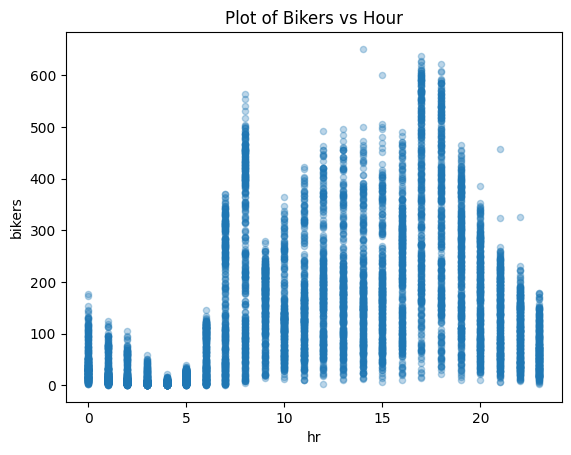

In [53]:
# scatter plot of hr versus bikers
ax = Bikeshare.plot.scatter('hr', 'bikers', alpha=0.3)
ax.set_title("Plot of Bikers vs Hour")

#### c. Use the sm.OLS() function to perform a multiple linear regression with bikers as the response and only hr and an intercept as predictors. Use the summarize() function to print the results, and calculate the MSE for this model.

In [54]:
Y = Bikeshare['bikers']
X = Bikeshare['hr']
X = sm.add_constant(X)

model = sm.OLS(Y, X)
results = model.fit()

residuals = results.resid
mse = (residuals**2).mean()

print(f'Results: \n{summarize(results)}\n')
print(f'Mean Squared Error: {mse}\n')



Results: 
          coef  std err       t  P>|t|
const  52.4482    2.564  20.453    0.0
hr      7.8926    0.190  41.483    0.0

Mean Squared Error: 14927.622307978458



#### d. Based on the scatterplot in (b), it seems possible that a degree 2 effect may improve the fit for the hr variable. Refit the model using hr, hr2, and the intercept as variables. Again provide the model results and MSE.

In [55]:
hr2 = Bikeshare['hr'] ** 2
Y = Bikeshare['bikers']
X = pd.DataFrame({'const': 1, 'hr': Bikeshare['hr'], 'hr2': hr2})

model = sm.OLS(Y, X)
results = model.fit()

residuals = results.resid
mse = (residuals**2).mean()

print(f'Results: \n{summarize(results)}\n')
print(f'Mean Squared Error: {mse}\n')

Results: 
          coef  std err       t  P>|t|
const -46.4378    3.336 -13.918    0.0
hr     34.7187    0.668  51.980    0.0
hr2    -1.1647    0.028 -41.594    0.0

Mean Squared Error: 12437.720822189804



#### e. We also see in the scatterplot in (b) that, on average, more bikes are used during commuting hours. This suggests a possible interaction between hr and workingday. Refit the model using hr, hr2, workingday, hr×workingday, and the intercept as variables. Again provide the model results and MSE.

In [56]:
working_day = Bikeshare['workingday']
hr_working_day = Bikeshare['hr'] * Bikeshare['workingday']
hr2 = Bikeshare['hr'] ** 2
Y = Bikeshare['bikers']
X = pd.DataFrame({'const': 1, 'hr': Bikeshare['hr'], 'hr2': hr2, 'working_day' : working_day, 'hr_working_day': hr_working_day})

model = sm.OLS(Y, X)
results = model.fit()

residuals = results.resid
mse = (residuals**2).mean()

print(f'Results: \n{summarize(results)}\n')
print(f'Mean Squared Error: {mse}\n')

Results: 
                   coef  std err       t  P>|t|
const          -41.9017    4.777  -8.771  0.000
hr              34.1591    0.714  47.835  0.000
hr2             -1.1649    0.028 -41.610  0.000
working_day     -6.6632    5.025  -1.326  0.185
hr_working_day   0.8237    0.373   2.206  0.027

Mean Squared Error: 12428.95706672807



#### f. In question (2), we saw that temp was predictive, so let’s add that to our model. Refit the model using hr, hr2, workingday, hr×workingday, temp, and the intercept as variables. Again provide the model results and MSE.

In [57]:
working_day = Bikeshare['workingday']
hr_working_day = Bikeshare['hr'] * Bikeshare['workingday']
hr2 = Bikeshare['hr'] ** 2
temp = Bikeshare['temp']

Y = Bikeshare['bikers']
X = pd.DataFrame({'const': 1, 'hr': Bikeshare['hr'], 'hr2': hr2, 'working_day' : working_day, 'hr_working_day': hr_working_day, 'temp': temp})

model = sm.OLS(Y, X)
results = model.fit()

residuals = results.resid
mse = (residuals**2).mean()

print(f'Results: \n{summarize(results)}\n')
print(f'Mean Squared Error: {mse}\n')

Results: 
                    coef  std err       t  P>|t|
const          -139.8046    4.793 -29.170  0.000
hr               30.3688    0.646  46.994  0.000
hr2              -1.0420    0.025 -41.234  0.000
working_day     -13.8377    4.513  -3.066  0.002
hr_working_day    0.9535    0.335   2.846  0.004
temp            252.1313    5.518  45.696  0.000

Mean Squared Error: 10009.578912400702



#### g. Noticing the improvement to MSE with each additional variable, you may decide to include many more predictors in your next iteration. What do you expect would happen to the MSE on the training data?

As more predictsors are added, I would expect the MSE to decrease since the model can fit the training data more closely. However, this comes with the risk of overfitting if the predictors are not relevant to the model.

#### h. Suppose you are given unseen holdout data from 2013 to use for testing. Which of these models would you expect to have the best performance? Why?

I would expect the final model using hr, hr2, workingday, hr*workingday, and temp to have the best performance on holdout data. This model takes in the main patterns of the hours of the day, along with the working day and temperature effects. It's not too overboard with the amount of predictors, and illustrates a good picture.